In [1]:
%%capture
%pip install punchbowl

In [2]:
from sunpy.map import Map
from sunpy.net import Fido
from sunpy.net import attrs as a

import glob

from punchbowl.data.punch_io import load_ndcube_from_fits
from punchbowl.data.visualize import cmap_punch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [3]:
!wget https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/PUNCH_L2_CTM_20250811002429_v0e.fits

--2025-08-21 15:51:45--  https://umbra.nascom.nasa.gov/punch/2/CTM/2025/08/11/PUNCH_L2_CTM_20250811002429_v0e.fits
Resolving umbra.nascom.nasa.gov (umbra.nascom.nasa.gov)... 198.118.248.134, 2001:4d0:14:100::134
Connecting to umbra.nascom.nasa.gov (umbra.nascom.nasa.gov)|198.118.248.134|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21715200 (21M) [image/fits]
Saving to: ‘PUNCH_L2_CTM_20250811002429_v0e.fits’

PUNCH_L2_CTM_202508 100%[===================>]  20.71M  62.2MB/s    in 0.3s    

2025-08-21 15:51:46 (62.2 MB/s) - ‘PUNCH_L2_CTM_20250811002429_v0e.fits’ saved [21715200/21715200]



In [4]:
files = glob.glob('*.fits')
files

['PUNCH_L2_CTM_20250811002429_v0e.fits']

In [5]:
cube = load_ndcube_from_fits(files[0])

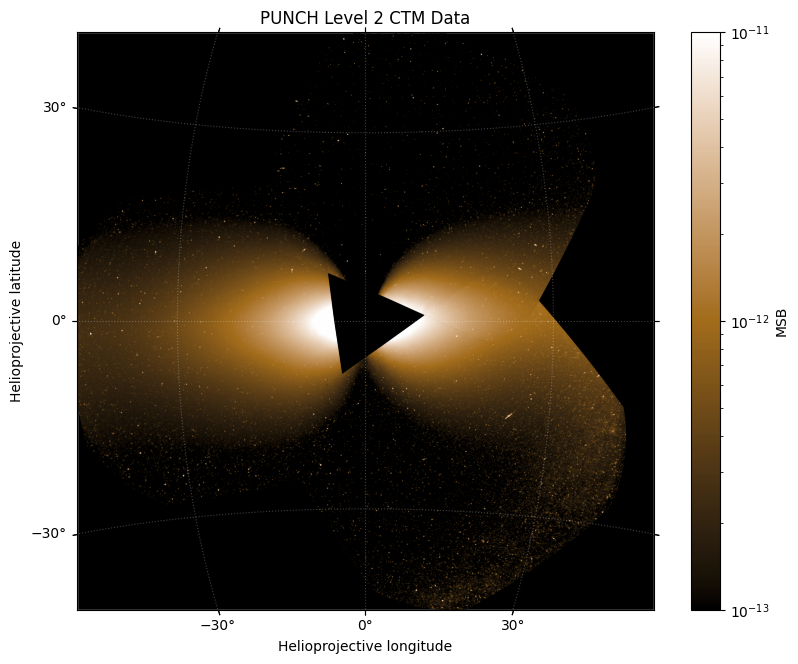

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={"projection":cube.wcs})

im = ax.imshow(cube.data, cmap=cmap_punch, norm=LogNorm(vmin=1e-13, vmax=1e-11))

lon, lat = ax.coords
lat.set_major_formatter("dd")
lon.set_major_formatter("dd")
ax.set_facecolor("black")
ax.coords.grid(color="white", alpha=.25, ls="dotted")
ax.set_xlabel("Helioprojective longitude")
ax.set_ylabel("Helioprojective latitude")
ax.set_title("PUNCH Level 2 CTM Data")
fig.colorbar(im, ax=ax, label="MSB")
plt.show()